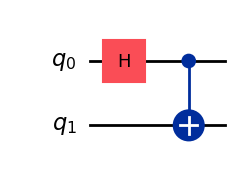

In [2]:
# Do a hello world example in a 2-qubit bell state
# Step 1: map the problem to circuits and operators

from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0) # hadamard gate
qc.cx(0, 1)

qc.draw(output='mpl')

In [3]:
from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')

observable_list = [ZZ, ZI, IZ, XX, XI, IX]

In [4]:
# Step 2: Optimize the circuit observables

In [5]:
# Step 3: Execute on the backend

from qiskit_aer.primitives import Estimator

estim = Estimator()

job = estim.run([qc] * len(observable_list), observable_list)

job.result()

EstimatorResult(values=array([ 1.        ,  0.        ,  0.        ,  1.        , -0.01953125,
       -0.01953125]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0090379, 'sample_measure_time': 0.0007299, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 15973, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 1.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0090379, 'sample_measure_time': 0.0007299, 'input_qubi

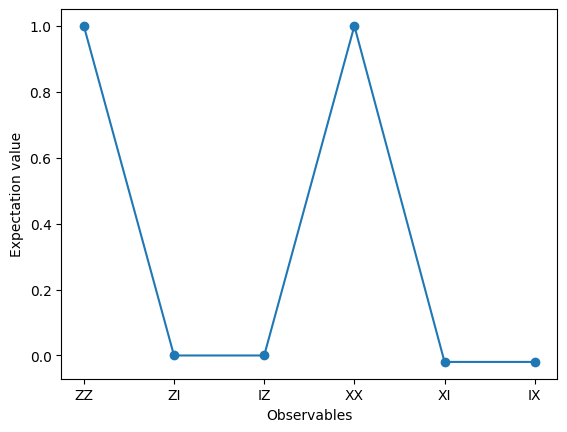

In [6]:
# Step 4: Post-processing and plotting the result

import matplotlib.pyplot as plot

data = ["ZZ", "ZI", "IZ", "XX", "XI", "IX"]
values = job.result().values

plot.plot(data, values, '-o')
plot.xlabel("Observables")
plot.ylabel("Expectation value")
plot.show()

Now we are going to extend the "Hello World" example to an $n$-qubit GHZ state

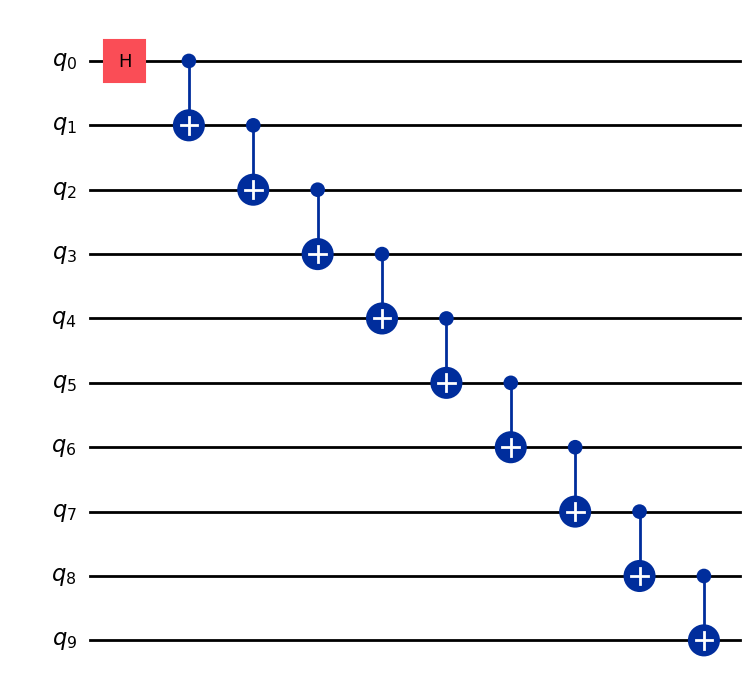

In [7]:
# Step 1: Map the problem to circuits and operators

def get_qc_for_n_qubit_GHZ_states(n):
    qc = QuantumCircuit(n) if n >= 1 else QuantumCircuit(1)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc       

n = 10
qc = get_qc_for_n_qubit_GHZ_states(n)

qc.draw(output='mpl')

In [54]:
from qiskit.quantum_info import SparsePauliOp

operator_strings = ['Z' + 'I' * i + 'Z' + 'I' * (n-2-i) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

['ZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [55]:
from qiskit_ibm_runtime import QiskitRuntimeService as QRS

service = QRS(channel='ibm_cloud', token='wnnqKixaV7UddXltqCLFEfYbaiyaml6cnbxZNNUg6wsc',
              instance='crn:v1:bluemix:public:quantum-computing:us-east:a/6b55d6bde5cc4cdd860a62812e6d41ba:d34921ce-dd7f-4ce8-b510-f077b4e106e6::')

qiskit_runtime_service._discover_account:WARNING:2026-06-09 17:01:02,385: Loading account with the given token. A saved account will not be used.


In [56]:
QRS.save_account(channel='ibm_cloud', token='wnnqKixaV7UddXltqCLFEfYbaiyaml6cnbxZNNUg6wsc', instance='crn:v1:bluemix:public:quantum-computing:us-east:a/6b55d6bde5cc4cdd860a62812e6d41ba:d34921ce-dd7f-4ce8-b510-f077b4e106e6::',
                 set_as_default=True, overwrite=True)

Now we will optimize the problem for quantum execution

In [57]:
from qiskit_ibm_runtime import QiskitRuntimeService as QRS
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager as gppm

backend_name = "ibm_kingston"
backend = QRS().backend(backend_name)
pass_manager = gppm(optimization_level=1, backend=backend)

qc_transpiled = pass_manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_transpiled.layout) for op in operators]


Now EXECUTE THE BACKEND

In [58]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator, EstimatorOptions

# Transpile the circuit
pm = gppm(backend=backend, optimization_level=1)                                       
isa_circuit = pm.run(qc)
isa_observable = [SparsePauliOp(op).apply_layout(isa_circuit.layout) for op in operators]

# Observable
options = EstimatorOptions(resilience_level=1)

# Run with Estimator
estimator = Estimator(mode=backend, options=options)
job = estimator.run([(isa_circuit, isa_observable)])

job_id = job.job_id()
print(job_id)

d8kaiig32u0s73f8h6m0


In [59]:
# Step 4: Post-processing and plotting result

job_id = 'd8kaiig32u0s73f8h6m0'
service = QRS()
job = service.job(job_id)

99

99


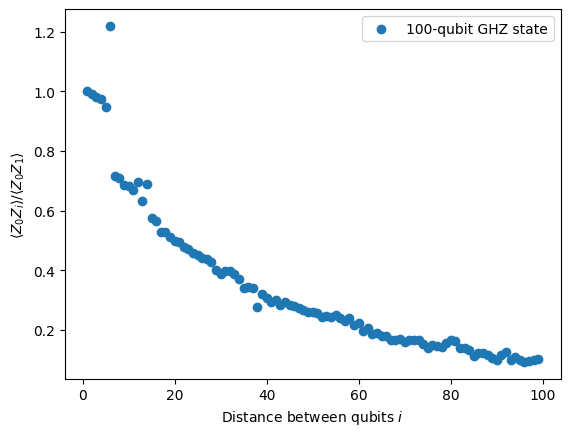

In [61]:
import matplotlib.pyplot as plt

data = list(range(1, len(operators) + 1))
result = job.result()[0]
values = result.data.evs
values = [v / values[0] for v in values]

print(len(data))
print()
print(len(values))

plt.scatter(data, values, marker='o', label='100-qubit GHZ state')
plt.xlabel('Distance between qubits $i$')
plt.ylabel(r'$\langle Z_0 Z_i \rangle / \langle Z_0 Z_1 \rangle$')
plt.legend()
plt.show()